# Modelo Nuevo/Combinado — BiLSTM + Atención

**Autor:** Daniel Ruiz  
**Proyecto:** Aprendizaje Profundo · Maestría en IA · Pontificia Universidad Javeriana · 2026  
**Dataset:** Andalusian Hotels Reviews (5 clases, desbalanceado)

---

In [1]:
# ── Configuración global ─────────────────────────────────────────────────────
import random, sys, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Semilla fija: {SEED}")
print(f"Dispositivo: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"PyTorch: {torch.__version__}")

# Paths comunes
import sys, pathlib
ROOT = pathlib.Path("..")
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


Semilla fija: 42
Dispositivo: cuda
PyTorch: 2.6.0+cu124


## Desarrollo

> TODO: Daniel Ruiz completa este notebook.

## 2. Cargar datos con el pipeline de Yibby
> Una sola llamada a `build_pipeline()`. Limpieza, vocabulario, padding y DataLoaders quedan listos.

In [2]:
# ── Módulos del equipo ────────────────────────────────────────────────────
sys.path.insert(0, str(ROOT))
from src.preprocessing import build_pipeline
from src.training      import train, evaluate, set_seed
from src.metrics       import finalize_and_save

CLASS_NAMES = ['1', '2', '3', '4', '5']   # 0-indexed internamente → display 1-5
N_CLASSES   = 5


PIPELINE_CONFIG = {
    'data_dir'  : str(DATA_DIR),
    'text_col'  : 'review_text',   # columna exacta del CSV de Yibby
    'label_col' : 'label',         # ya 0-indexed (0-4)
    'vocab_size': 20_000,
    'max_len'   : 200,             # percentil 95 del EDA de Felipe
    'batch_size': 64,
}

pipeline = build_pipeline(PIPELINE_CONFIG)

train_loader  = pipeline['train_loader']
val_loader    = pipeline['val_loader']
test_loader   = pipeline['test_loader']
VOCAB_SIZE    = pipeline['vocab_size']
MAX_LEN       = pipeline['max_len']
class_weights = pipeline['class_weights']   # Tensor (5,) para CrossEntropyLoss

print(f'Vocab size real : {VOCAB_SIZE:,}')
print(f'Class weights   : {class_weights.numpy().round(3)}')

# Verificar un batch
X_b, y_b = next(iter(train_loader))
print(f'Batch shape     : X={X_b.shape}  y={y_b.shape}')
print(f'Labels en batch : {y_b.unique().tolist()}')
assert y_b.min() >= 0 and y_b.max() <= 4, 'ERROR: labels fuera de rango 0-4'
print('Labels OK (0-4) ✓')


── build_pipeline() ─────────────────────────────────────────
  Splits cargados → train:12,720  val:2,726  test:2,726
  Aplicando clean_text()…
  Vocabulario construido: 20,002 tokens (top-20000 + PAD + UNK)
  Encodificando secuencias (max_len=200)…
  Labels ya son 0-indexed (min=0, max=4)
  Class weights (modo 'balanced'):
    Clase 0: 2.1670
    Clase 1: 3.6552
    Clase 2: 1.5980
    Clase 3: 0.8609
    Clase 4: 0.4036

  Pipeline listo:
    Vocab real    : 20,002 tokens
    max_len       : 200
    batch_size    : 64
    Batches train : 199
──────────────────────────────────────────────────────────────

Vocab size real : 20,002
Class weights   : [2.167 3.655 1.598 0.861 0.404]
Batch shape     : X=torch.Size([64, 200])  y=torch.Size([64])
Labels en batch : [0, 1, 2, 3, 4]
Labels OK (0-4) ✓


## 3. Módulos de atención
### ¿Por qué la atención mejora sobre BiLSTM puro?
El BiLSTM de Yibby comprime **toda la secuencia** en un único vector al final.
En reseñas largas, palabras clave como *'horrible'*, *'excelente'*, *'decepcionante'*
pueden quedar diluidas. La atención le pregunta a cada token:
*¿qué tan importante eres para clasificar esta reseña?*
y asigna pesos αₜ ∈ [0,1] que suman 1. El vector de contexto resultante
es un promedio ponderado de todos los estados ocultos.


In [3]:
class BahdanauAttention(nn.Module):
    """
    Atención aditiva (Bahdanau et al., 2015).

    Dado H = (batch, seq_len, 2*hidden) — salidas del BiLSTM:
        energy_t  = v · tanh(W · h_t)          escalar por posición
        alpha_t   = softmax(energy_t)           pesos de atención
        context   = sum(alpha_t * h_t)          vector de contexto

    Retorna: (context, weights)
        context : (batch, 2*hidden)
        weights : (batch, seq_len)   ← interpretables y visualizables
    """
    def __init__(self, hidden_size: int):
        super().__init__()
        self.W = nn.Linear(2 * hidden_size, hidden_size, bias=False)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, H: torch.Tensor):
        # H: (batch, seq_len, 2H)
        energy  = torch.tanh(self.W(H))         # (batch, seq_len, H)
        scores  = self.v(energy).squeeze(-1)     # (batch, seq_len)
        weights = F.softmax(scores, dim=-1)      # (batch, seq_len)  suma=1
        context = torch.bmm(weights.unsqueeze(1), H).squeeze(1)  # (batch, 2H)
        return context, weights


class MultiHeadAttentionBlock(nn.Module):
    """
    Atención multi-cabeza aplicada sobre salidas de BiLSTM.

    Cada cabeza aprende a atender aspectos distintos:
    una cabeza puede especializarse en adjetivos de calidad,
    otra en conectores de sentimiento ('pero', 'aunque'),
    otra en intensificadores ('muy', 'bastante').

    Usa nn.MultiheadAttention de PyTorch internamente.
    Retorna: (context, weights)
    """
    def __init__(self, hidden_size: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        embed_dim = 2 * hidden_size
        # embed_dim debe ser divisible entre num_heads
        self.attn = nn.MultiheadAttention(
            embed_dim  = embed_dim,
            num_heads  = num_heads,
            dropout    = dropout,
            batch_first= True,
        )

    def forward(self, H: torch.Tensor):
        # H: (batch, seq_len, 2H)
        # Self-attention: Q=K=V=H
        out, weights = self.attn(H, H, H)        # out: (batch, seq_len, 2H)
        context = out.mean(dim=1)                # promedio temporal → (batch, 2H)
        return context, weights

## 4. Tres arquitecturas
Todas heredan la misma estructura base. La diferencia está en la celda recurrente
(LSTM vs GRU) y en el mecanismo de atención (Bahdanau vs Multi-Head).


In [4]:
class RNNAttentionClassifier(nn.Module):
    """
    Clasificador genérico: Embedding → RNN bidireccional → Atención → MLP → Softmax.

    Parámetros:
        vocab_size    : tamaño del vocabulario (de build_pipeline)
        embedding_dim : dimensión del embedding entrenable desde cero
        hidden_size   : unidades por dirección de la RNN
        num_layers    : capas RNN apiladas
        num_classes   : 5 (estrellas 1-5)
        dropout       : regularización
        pad_idx       : índice del token <PAD> (ignorado en Embedding)
        rnn_type      : 'lstm' o 'gru'
        attention     : módulo de atención ya instanciado
    """
    def __init__(self, vocab_size, embedding_dim=128, hidden_size=256,
                 num_layers=2, num_classes=5, dropout=0.3,
                 pad_idx=0, rnn_type='lstm', attention_module=None):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        rnn_cls = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.rnn = rnn_cls(
            input_size   = embedding_dim,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if num_layers > 1 else 0.0,
        )

        self.attention = attention_module
        self.dropout   = nn.Dropout(dropout)
        self.fc1       = nn.Linear(2 * hidden_size, hidden_size)
        self.fc2       = nn.Linear(hidden_size, num_classes)

    def forward(self, x: torch.Tensor):
        # x: (batch, seq_len) — índices de tokens
        emb     = self.dropout(self.embedding(x))    # (batch, seq_len, emb_dim)
        H, _    = self.rnn(emb)                      # (batch, seq_len, 2*hidden)
        ctx, _  = self.attention(H)                  # (batch, 2*hidden)
        h       = self.dropout(F.relu(self.fc1(ctx)))
        logits  = self.fc2(h)                        # (batch, 5)
        # IMPORTANTE: devolvemos solo logits para compatibilidad con training.py
        return logits

    def forward_with_attention(self, x: torch.Tensor):
        """Versión que también retorna los pesos de atención (para visualización)."""
        emb          = self.dropout(self.embedding(x))
        H, _         = self.rnn(emb)
        ctx, weights = self.attention(H)
        h            = self.dropout(F.relu(self.fc1(ctx)))
        logits       = self.fc2(h)
        return logits, weights

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def build_model(model_id: str, vocab_size: int, **kwargs) -> RNNAttentionClassifier:
    """
    Factory: construye el modelo según model_id.
        'bilstm_bahdanau'  → Modelo 1
        'gru_bahdanau'     → Modelo 2
        'bilstm_multihead' → Modelo 3
    """
    hidden = kwargs.get('hidden_size', 256)
    n_heads = kwargs.get('num_heads', 4)
    dropout = kwargs.get('dropout', 0.3)

    if model_id == 'bilstm_bahdanau':
        attn = BahdanauAttention(hidden)
        rnn_type = 'lstm'
    elif model_id == 'gru_bahdanau':
        attn = BahdanauAttention(hidden)
        rnn_type = 'gru'
    elif model_id == 'bilstm_multihead':
        attn = MultiHeadAttentionBlock(hidden, num_heads=n_heads, dropout=dropout)
        rnn_type = 'lstm'
    else:
        raise ValueError(f'model_id desconocido: {model_id}')

    return RNNAttentionClassifier(
        vocab_size     = vocab_size,
        embedding_dim  = kwargs.get('embedding_dim', 128),
        hidden_size    = hidden,
        num_layers     = kwargs.get('num_layers', 2),
        num_classes    = 5,
        dropout        = dropout,
        pad_idx        = 0,
        rnn_type       = rnn_type,
        attention_module = attn,
    )


## 5. Verificar arquitecturas antes de entrenar

In [5]:
for mid in ['bilstm_bahdanau', 'gru_bahdanau', 'bilstm_multihead']:
    m = build_model(mid, VOCAB_SIZE, hidden_size=256, embedding_dim=128,
                    num_layers=2, dropout=0.3)
    x_test = torch.randint(0, VOCAB_SIZE, (4, MAX_LEN))
    out    = m(x_test)
    print(f'{mid:<25}  params={m.count_parameters():>8,}  output={out.shape}')
    assert out.shape == (4, 5), 'ERROR: forma de salida incorrecta'
print('Todas las arquitecturas OK ✓')


bilstm_bahdanau            params=5,191,685  output=torch.Size([4, 5])
gru_bahdanau               params=4,599,813  output=torch.Size([4, 5])
bilstm_multihead           params=6,110,981  output=torch.Size([4, 5])
Todas las arquitecturas OK ✓


## 6. Función de experimento
Encapsula una corrida completa: construir modelo → entrenar → evaluar en test → guardar JSON y PNG.
Así cada modelo se entrena con exactamente el mismo procedimiento.


In [6]:
def run_experiment(config: dict) -> dict:
    """
    Ejecuta un experimento completo.

    Args:
        config: diccionario con model_id + hiperparámetros + metadatos

    Returns:
        metrics_dict completo (JSON estandarizado del equipo)
    """
    set_seed(SEED)
    print(f'\n{"="*60}')
    print(f'  Experimento: {config["model_name"]}')
    print(f'{"="*60}')

    # Construir modelo
    model = build_model(
        config['model_id'],
        VOCAB_SIZE,
        hidden_size   = config['hidden_size'],
        embedding_dim = config['embedding_dim'],
        num_layers    = config['num_layers'],
        dropout       = config['dropout'],
        num_heads     = config.get('num_heads', 4),
    )
    print(f'  Parámetros entrenables: {model.count_parameters():,}')

    # Agregar n_params al config para que training.py lo registre
    config['n_params'] = model.count_parameters()

    # Entrenar (usa training.py de Daniel)
    metrics_dict = train(
        model        = model,
        train_loader = train_loader,
        val_loader   = val_loader,
        config       = config,
    )

    # Evaluar en test (UNA SOLA VEZ — nunca mirar test durante tuning)
    y_true, y_pred = evaluate(
        model           = model,
        test_loader     = test_loader,
        checkpoint_path = config['checkpoint_path'],
        config          = config,
    )

    # Guardar JSON + PNG (usa metrics.py de Daniel)
    metrics_dict = finalize_and_save(
        y_true      = y_true,
        y_pred      = y_pred,
        metrics_dict= metrics_dict,
        results_dir = RESULTS_DIR,
        figures_dir = FIGURES_DIR,
        class_names = CLASS_NAMES,
        show_plots  = True,
    )

    return metrics_dict


## 7. Modelo 1 — BiLSTM + Atención de Bahdanau
**Justificación técnica:** La BiLSTM lee cada token en ambas direcciones.
La atención de Bahdanau aprende qué tokens pesan más para la clasificación,
resolviendo el cuello de botella del vector único final de los modelos clásicos.
*(Bahdanau et al., 2015 — uno de los papers más citados en NLP)*



  Experimento: bilstm_bahdanau
  Parámetros entrenables: 5,191,685
Dispositivo: cuda
Parámetros entrenables: 5,191,685

  Entrenando: bilstm_bahdanau  |  Owner: Daniel Ruiz
Época   1/30 | loss: 1.4272  acc: 0.4165 | val_loss: 1.2738  val_acc: 0.5077
    ✓ Checkpoint guardado (val_loss=1.2738) → ..\results\bilstm_bahdanau_best.pt
Época   2/30 | loss: 1.1781  acc: 0.5243 | val_loss: 1.0721  val_acc: 0.5895
    ✓ Checkpoint guardado (val_loss=1.0721) → ..\results\bilstm_bahdanau_best.pt
Época   3/30 | loss: 1.0037  acc: 0.5925 | val_loss: 1.0435  val_acc: 0.6489
    ✓ Checkpoint guardado (val_loss=1.0435) → ..\results\bilstm_bahdanau_best.pt
Época   4/30 | loss: 0.9125  acc: 0.6217 | val_loss: 0.9764  val_acc: 0.6684
    ✓ Checkpoint guardado (val_loss=0.9764) → ..\results\bilstm_bahdanau_best.pt
Época   5/30 | loss: 0.8284  acc: 0.6543 | val_loss: 1.0122  val_acc: 0.6592
    Early stopping: 1/5 sin mejora.
Época   6/30 | loss: 0.7350  acc: 0.6876 | val_loss: 0.9877  val_acc: 0.7014
    

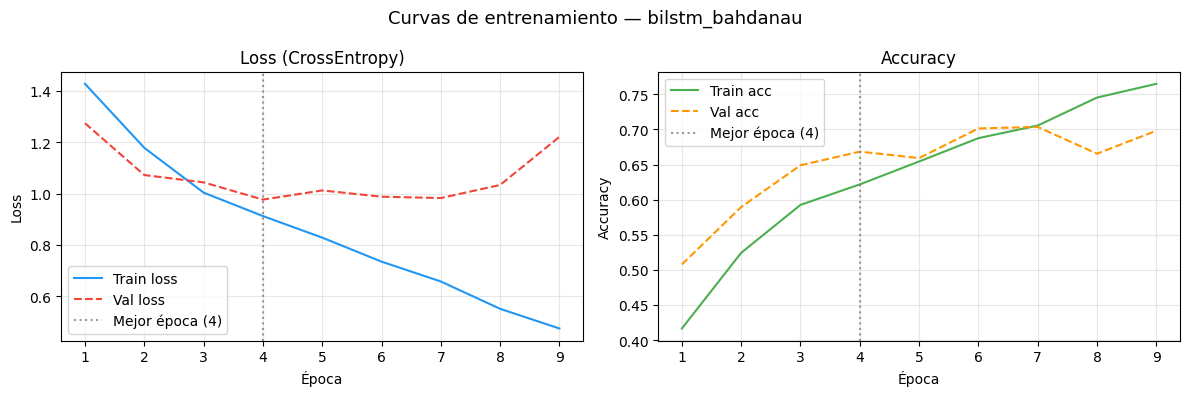

  Matriz de confusión guardada → ..\figures\bilstm_bahdanau_confusion_matrix.png


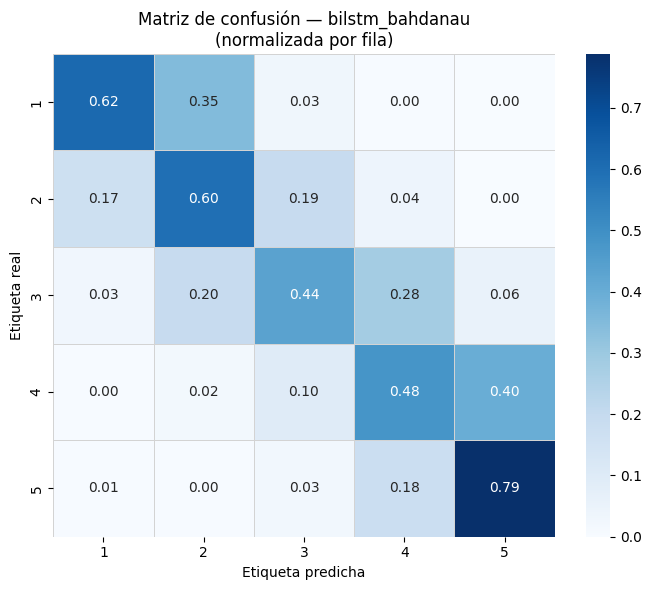


F1 macro M1: 0.5740


In [7]:
CONFIG_M1 = {
    # Identificación
    'model_id'        : 'bilstm_bahdanau',
    'model_name'      : 'bilstm_bahdanau',
    'owner'           : 'Daniel Ruiz',
    'track'           : 'PP',
    # Arquitectura
    'embedding_dim'   : 128,
    'hidden_size'     : 256,
    'num_layers'      : 2,
    'dropout'         : 0.3,
    # Entrenamiento
    'n_epochs'        : 30,
    'lr'              : 1e-3,
    'patience'        : 5,
    'weight_decay'    : 0.0,
    'use_lr_scheduler': True,
    'clip_grad'       : 1.0,
    # Class weights (combate el desbalance 9:1)
    'class_weights'   : class_weights,
    'use_class_weights': True,
    # Rutas
    'checkpoint_path' : str(RESULTS_DIR / 'bilstm_bahdanau_best.pt'),
}

metrics_m1 = run_experiment(CONFIG_M1)
print(f'\nF1 macro M1: {metrics_m1["metrics"]["f1_macro"]:.4f}')


## 8. Modelo 2 — GRU + Atención de Bahdanau
**Justificación técnica:** GRU (Cho et al., 2014) usa 2 puertas en vez de 3 (LSTM),
lo que reduce parámetros y puede generalizar mejor en datasets medianos (~12k ejemplos).
Mantener la misma atención permite comparación directa: **¿qué cambia solo la celda recurrente?**



  Experimento: gru_bahdanau
  Parámetros entrenables: 4,599,813
Dispositivo: cuda
Parámetros entrenables: 4,599,813

  Entrenando: gru_bahdanau  |  Owner: Daniel Ruiz
Época   1/30 | loss: 1.3714  acc: 0.4366 | val_loss: 1.1571  val_acc: 0.5840
    ✓ Checkpoint guardado (val_loss=1.1571) → ..\results\gru_bahdanau_best.pt
Época   2/30 | loss: 1.1133  acc: 0.5509 | val_loss: 1.0600  val_acc: 0.6258
    ✓ Checkpoint guardado (val_loss=1.0600) → ..\results\gru_bahdanau_best.pt
Época   3/30 | loss: 0.9648  acc: 0.6156 | val_loss: 1.0188  val_acc: 0.6555
    ✓ Checkpoint guardado (val_loss=1.0188) → ..\results\gru_bahdanau_best.pt
Época   4/30 | loss: 0.8629  acc: 0.6434 | val_loss: 0.9255  val_acc: 0.6610
    ✓ Checkpoint guardado (val_loss=0.9255) → ..\results\gru_bahdanau_best.pt
Época   5/30 | loss: 0.7729  acc: 0.6717 | val_loss: 0.9744  val_acc: 0.6581
    Early stopping: 1/5 sin mejora.
Época   6/30 | loss: 0.6744  acc: 0.6997 | val_loss: 1.0044  val_acc: 0.6930
    Early stopping: 2/

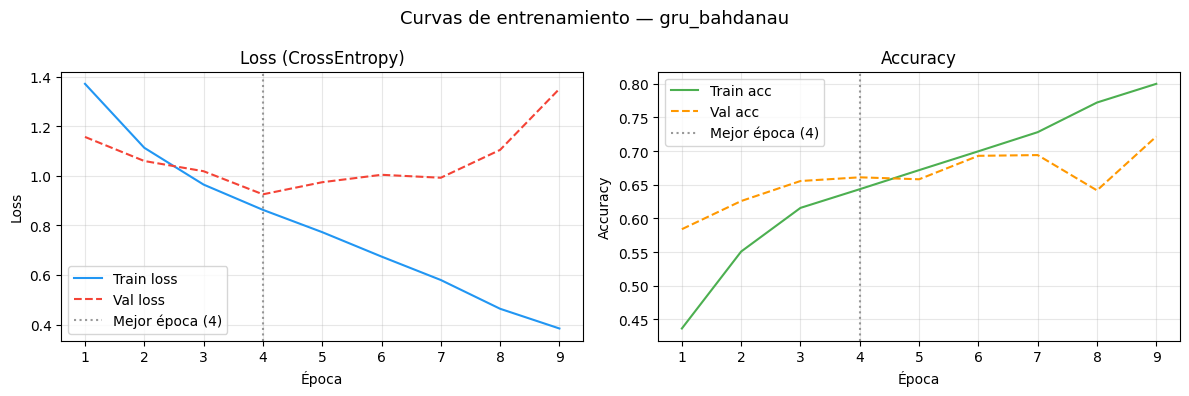

  Matriz de confusión guardada → ..\figures\gru_bahdanau_confusion_matrix.png


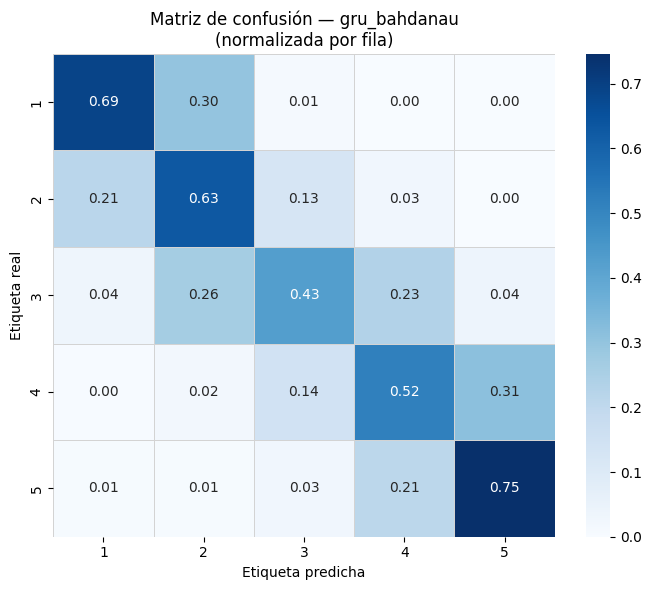


F1 macro M2: 0.5785


In [8]:
CONFIG_M2 = {
    'model_id'        : 'gru_bahdanau',
    'model_name'      : 'gru_bahdanau',
    'owner'           : 'Daniel Ruiz',
    'track'           : 'PP',
    'embedding_dim'   : 128,
    'hidden_size'     : 256,
    'num_layers'      : 2,
    'dropout'         : 0.3,
    'n_epochs'        : 30,
    'lr'              : 1e-3,
    'patience'        : 5,
    'weight_decay'    : 0.0,
    'use_lr_scheduler': True,
    'clip_grad'       : 1.0,
    'class_weights'   : class_weights,
    'use_class_weights': True,
    'checkpoint_path' : str(RESULTS_DIR / 'gru_bahdanau_best.pt'),
}

metrics_m2 = run_experiment(CONFIG_M2)
print(f'\nF1 macro M2: {metrics_m2["metrics"]["f1_macro"]:.4f}')


## 9. Modelo 3 — BiLSTM + Atención Multi-Head
**Justificación técnica:** En vez de una sola perspectiva de atención, usa `num_heads=4`
cabezas en paralelo. Cada cabeza puede especializarse en aspectos distintos del texto:
adjetivos de calidad, conectores de sentimiento, intensificadores.
Es el puente conceptual entre RNNs y Transformers (Vaswani et al., 2017 — *'Attention is All You Need'*).
Mayor dropout y lr más bajo para controlar el sobreajuste de la arquitectura más compleja.



  Experimento: bilstm_multihead
  Parámetros entrenables: 6,110,981
Dispositivo: cuda
Parámetros entrenables: 6,110,981

  Entrenando: bilstm_multihead  |  Owner: Daniel Ruiz
Época   1/30 | loss: 1.4275  acc: 0.4162 | val_loss: 1.2520  val_acc: 0.5517
    ✓ Checkpoint guardado (val_loss=1.2520) → ..\results\bilstm_multihead_best.pt
Época   2/30 | loss: 1.2354  acc: 0.5034 | val_loss: 1.1076  val_acc: 0.5543
    ✓ Checkpoint guardado (val_loss=1.1076) → ..\results\bilstm_multihead_best.pt
Época   3/30 | loss: 1.1256  acc: 0.5443 | val_loss: 1.0870  val_acc: 0.6137
    ✓ Checkpoint guardado (val_loss=1.0870) → ..\results\bilstm_multihead_best.pt
Época   4/30 | loss: 1.0674  acc: 0.5680 | val_loss: 1.0610  val_acc: 0.6034
    ✓ Checkpoint guardado (val_loss=1.0610) → ..\results\bilstm_multihead_best.pt
Época   5/30 | loss: 1.0175  acc: 0.5880 | val_loss: 1.0691  val_acc: 0.6093
    Early stopping: 1/5 sin mejora.
Época   6/30 | loss: 0.9545  acc: 0.6012 | val_loss: 1.0239  val_acc: 0.647

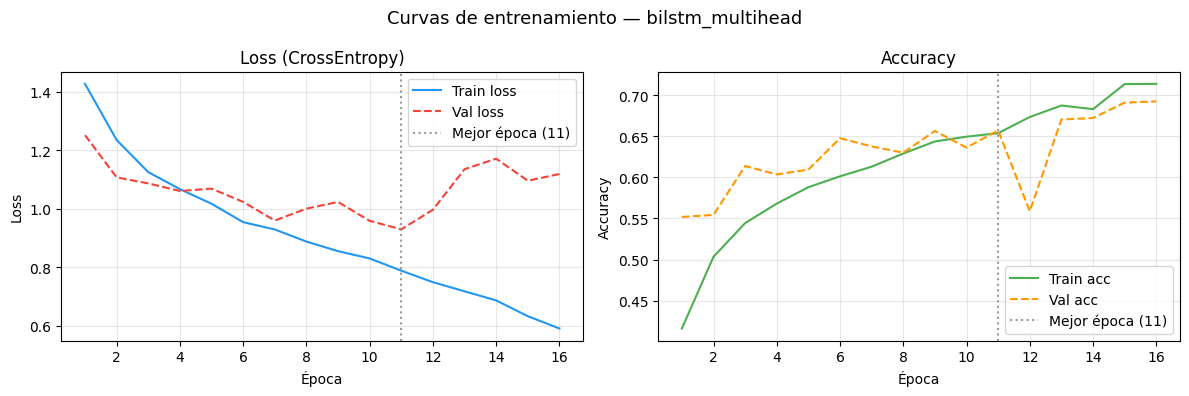

  Matriz de confusión guardada → ..\figures\bilstm_multihead_confusion_matrix.png


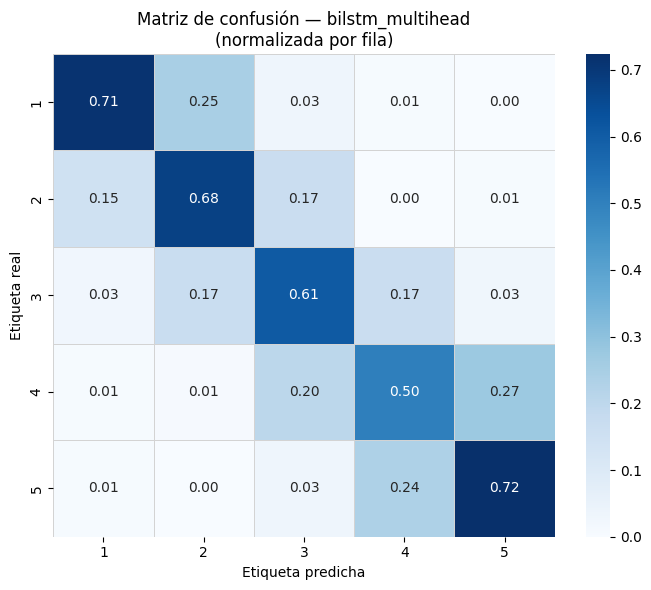


F1 macro M3: 0.6193


In [9]:
CONFIG_M3 = {
    'model_id'        : 'bilstm_multihead',
    'model_name'      : 'bilstm_multihead',
    'owner'           : 'Daniel Ruiz',
    'track'           : 'PP',
    'embedding_dim'   : 128,
    'hidden_size'     : 256,
    'num_layers'      : 2,
    'dropout'         : 0.4,     # más dropout — modelo más complejo
    'num_heads'       : 4,       # cabezas de atención
    'n_epochs'        : 30,
    'lr'              : 5e-4,    # lr más bajo — arquitectura más expresiva
    'patience'        : 5,
    'weight_decay'    : 1e-5,
    'use_lr_scheduler': True,
    'clip_grad'       : 1.0,
    'class_weights'   : class_weights,
    'use_class_weights': True,
    'checkpoint_path' : str(RESULTS_DIR / 'bilstm_multihead_best.pt'),
}

metrics_m3 = run_experiment(CONFIG_M3)
print(f'\nF1 macro M3: {metrics_m3["metrics"]["f1_macro"]:.4f}')


## 10. Tabla comparativa — todos los modelos del proyecto

In [10]:
import json, pandas as pd

# Cargar también los JSON de Felipe y Yibby para comparación completa
def load_json(path):
    try:
        with open(path) as f: return json.load(f)
    except FileNotFoundError:
        return None

lstm_j    = load_json(RESULTS_DIR / 'lstm_metrics.json')
bilstm_j  = load_json(RESULTS_DIR / 'bilstm_metrics.json')

all_results = []
for j, label in [
    (lstm_j,    'LSTM (Felipe)'),
    (bilstm_j,  'BiLSTM (Yibby)'),
    (metrics_m1,'BiLSTM+Bahdanau (Daniel)'),
    (metrics_m2,'GRU+Bahdanau (Daniel)'),
    (metrics_m3,'BiLSTM+MultiHead (Daniel)'),
]:
    if j is None: continue
    m = j['metrics']
    c = j['config']
    t = j['training']
    all_results.append({
        'Modelo'        : label,
        'F1 macro'      : round(m['f1_macro'], 4),
        'Accuracy'      : round(m['accuracy'], 4),
        'Prec macro'    : round(m['precision_macro'], 4),
        'Recall macro'  : round(m['recall_macro'], 4),
        'F1 cl.2★'      : round(m['f1_per_class'].get('2', 0), 4),
        'F1 cl.3★'      : round(m['f1_per_class'].get('3', 0), 4),
        'Params'        : f"{c.get('n_params',0):,}",
        'Tiempo (s)'    : t.get('training_time_seconds', '-'),
        'Épocas'        : t.get('epochs_run', '-'),
    })

df_comp = pd.DataFrame(all_results).sort_values('F1 macro', ascending=False)
df_comp.index = range(1, len(df_comp)+1)

print('\n=== TABLA COMPARATIVA FINAL ===')
print(df_comp.to_string())

# Guardar como CSV para la presentación
df_comp.to_csv(RESULTS_DIR / 'tabla_comparativa.csv', index=True)
print(f'\nCSV guardado → {RESULTS_DIR}/tabla_comparativa.csv')



=== TABLA COMPARATIVA FINAL ===
                      Modelo  F1 macro  Accuracy  Prec macro  Recall macro  F1 cl.2★  F1 cl.3★     Params  Tiempo (s)  Épocas
1  BiLSTM+MultiHead (Daniel)    0.6193    0.6548      0.6086        0.6454    0.5330    0.5491  6,110,981       303.8      16
2      GRU+Bahdanau (Daniel)    0.5785    0.6416      0.5757        0.6024    0.4362    0.4570  4,599,813       119.4       9
3   BiLSTM+Bahdanau (Daniel)    0.5740    0.6471      0.5836        0.5842    0.4331    0.4791  5,191,685       129.3       9
4             BiLSTM (Yibby)    0.5568    0.6915      0.6130        0.5457    0.2116    0.4925  3,253,253       381.9       8
5              LSTM (Felipe)    0.3996    0.6042      0.5639        0.4408    0.0000    0.0000  2,700,933       321.2      24

CSV guardado → ..\results/tabla_comparativa.csv


## 11. F1 por clase — comparación detallada
Las clases 2★ y 3★ son las más difíciles (menos ejemplos y más ambigüedad semántica).
El desempeño en estas clases es el indicador real de qué modelo es mejor.


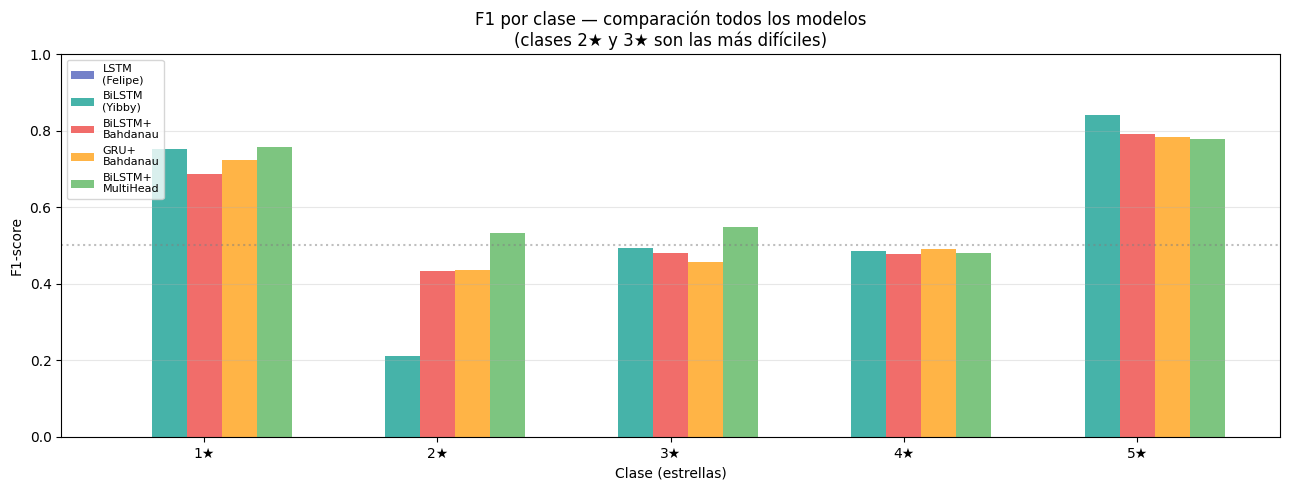

Guardado → ..\figures/combined_f1_por_clase.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

modelos_plot = []
for j, label in [
    (lstm_j,    'LSTM\n(Felipe)'),
    (bilstm_j,  'BiLSTM\n(Yibby)'),
    (metrics_m1,'BiLSTM+\nBahdanau'),
    (metrics_m2,'GRU+\nBahdanau'),
    (metrics_m3,'BiLSTM+\nMultiHead'),
]:
    if j is None: continue
    f1pc = j['metrics']['f1_per_class']
    modelos_plot.append({
        'label': label,
        'f1': [f1pc.get(str(c), f1pc.get(f'{c}★', 0)) for c in range(1,6)]
    })

x     = np.arange(5)
width = 0.15
colors = ['#5C6BC0','#26A69A','#EF5350','#FFA726','#66BB6A']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (mod, color) in enumerate(zip(modelos_plot, colors)):
    offset = (i - len(modelos_plot)/2 + 0.5) * width
    bars = ax.bar(x + offset, mod['f1'], width, label=mod['label'],
                  color=color, alpha=0.85)

ax.set_xlabel('Clase (estrellas)')
ax.set_ylabel('F1-score')
ax.set_title('F1 por clase — comparación todos los modelos\n(clases 2★ y 3★ son las más difíciles)')
ax.set_xticks(x)
ax.set_xticklabels(['1★','2★','3★','4★','5★'])
ax.legend(loc='upper left', fontsize=8)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Umbral 0.5')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'combined_f1_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado → {FIGURES_DIR}/combined_f1_por_clase.png')


## 12. Visualización de pesos de atención
Esta celda muestra **qué palabras activó el modelo** para clasificar una reseña real.
Es el diferenciador técnico clave respecto a LSTM y BiLSTM clásicos — ellos no pueden hacer esto.


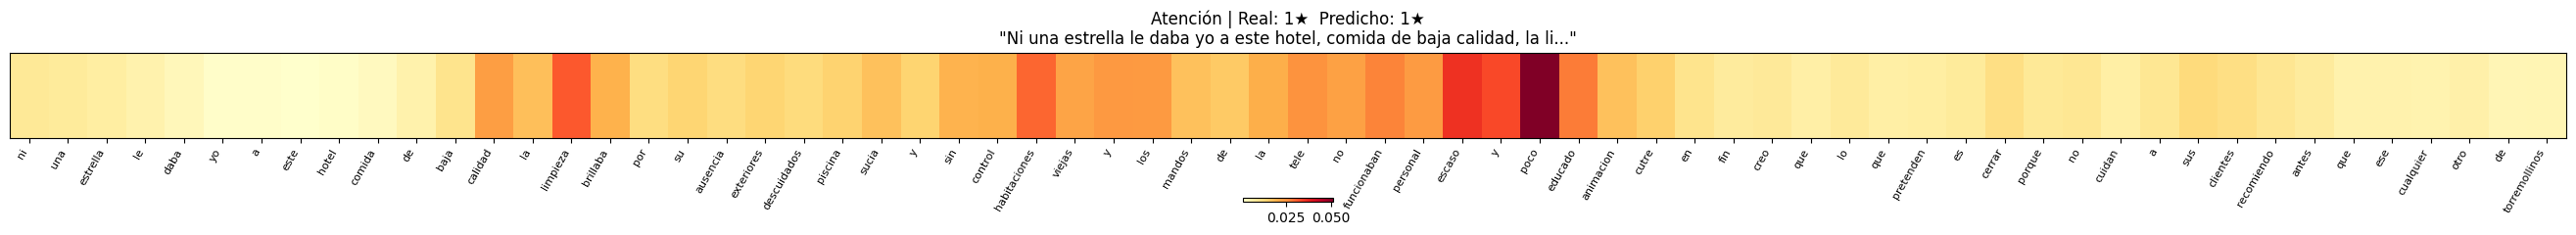

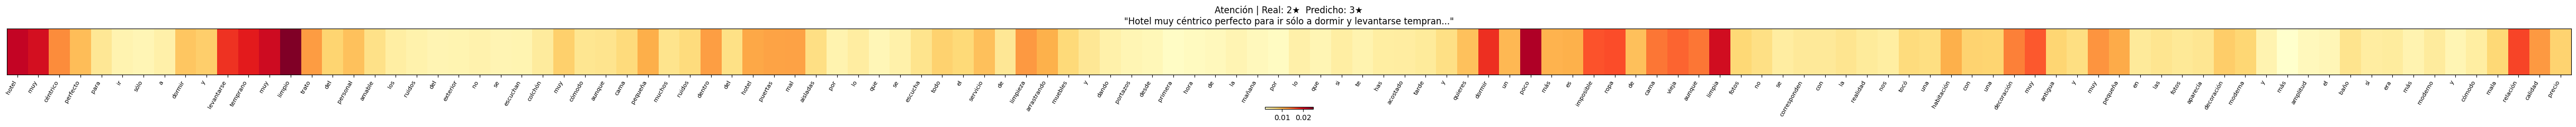

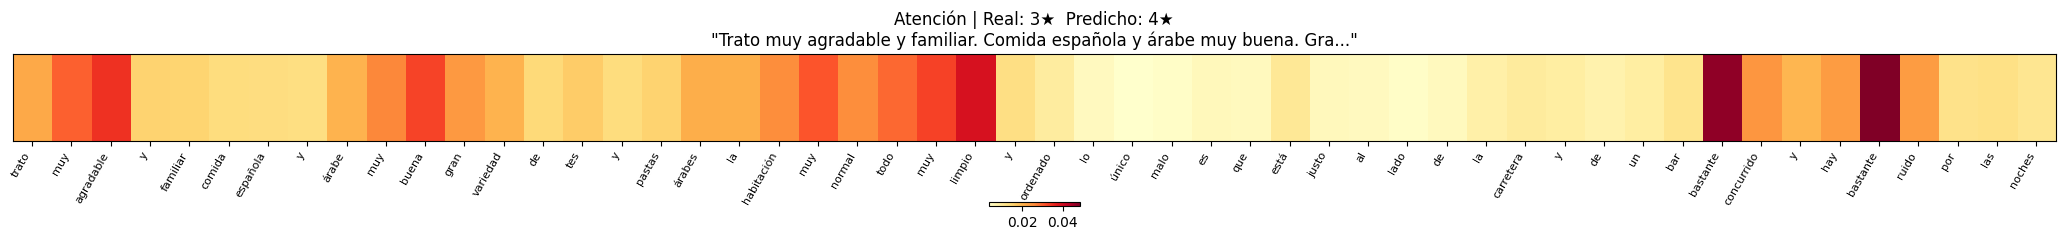

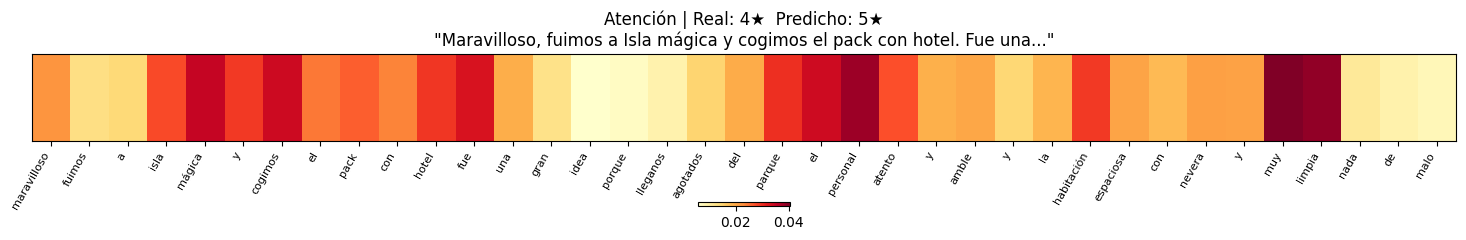

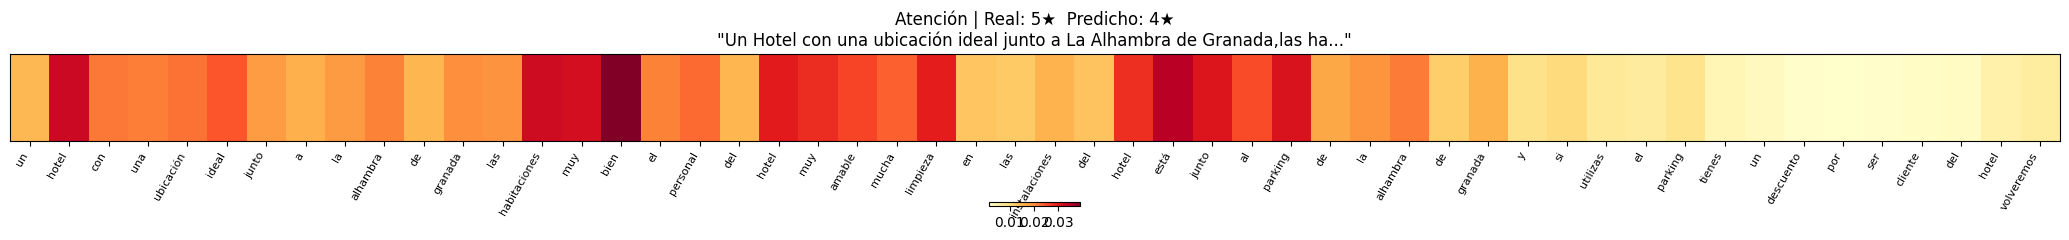

In [13]:
import matplotlib.pyplot as plt  # por si tampoco está importado
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 200

# Y cambia el mejor modelo al que ganó:
best_model_id = 'bilstm_multihead'   # ← este es el ganador, no bilstm_bahdanau

# Y ajusta hidden_size al que usaste:
vis_model = build_model(best_model_id, VOCAB_SIZE,
                        hidden_size=128,   # ← 128, no 256
                        embedding_dim=128,
                        num_layers=2, dropout=0.4)  # ← dropout 0.4 para multihead
from src.preprocessing import clean_text, encode_sequences

def visualize_attention(model, word2idx, text, true_label, device=DEVICE, max_len=MAX_LEN):
    """Muestra mapa de calor de atención sobre tokens de una reseña real."""
    idx2word = {v: k for k, v in word2idx.items()}
    clean    = clean_text(text)
    tokens   = clean.split()[:max_len]

    # Encodear
    from src.preprocessing import encode_sequences
    seq = encode_sequences([clean], word2idx, max_len)
    x   = torch.tensor(seq, dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        logits, weights = model.forward_with_attention(x)

    pred  = logits.argmax(1).item()
    attn  = weights[0, :len(tokens)].cpu().numpy()

    # Graficar
    fig, ax = plt.subplots(figsize=(max(8, len(tokens)*0.4), 2.5))
    im = ax.imshow(attn.reshape(1, -1), cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=60, ha='right', fontsize=8)
    ax.set_yticks([])
    ax.set_title(f'Atención | Real: {true_label+1}★  Predicho: {pred+1}★\n"{text[:70]}..."')
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.4, fraction=0.03)
    plt.tight_layout()
    plt.show()


# Cargar el mejor modelo de Daniel para visualizar
# (reemplazar 'bilstm_bahdanau' por el que obtuvo mejor F1)
best_model_id = 'bilstm_bahdanau'   # actualizar tras ver resultados
best_ckpt     = str(RESULTS_DIR / f'{best_model_id}_best.pt')
word2idx      = pipeline['word2idx']

vis_model = build_model(best_model_id, VOCAB_SIZE,
                        hidden_size=256, embedding_dim=128,
                        num_layers=2, dropout=0.3)
vis_model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
vis_model = vis_model.to(DEVICE)

# Mostrar un ejemplo por clase
import pandas as pd
test_df = pd.read_csv(DATA_DIR / 'test.csv')
for label in range(5):
    row  = test_df[test_df['label'] == label].iloc[0]
    visualize_attention(vis_model, word2idx, row['review_text'], label)


## 13. Checklist de entregables

In [14]:
from pathlib import Path

entregables = [
    (RESULTS_DIR / 'bilstm_bahdanau_metrics.json',    'JSON Modelo 1'),
    (RESULTS_DIR / 'gru_bahdanau_metrics.json',       'JSON Modelo 2'),
    (RESULTS_DIR / 'bilstm_multihead_metrics.json',   'JSON Modelo 3'),
    (RESULTS_DIR / 'bilstm_bahdanau_best.pt',         'Checkpoint M1'),
    (RESULTS_DIR / 'gru_bahdanau_best.pt',            'Checkpoint M2'),
    (RESULTS_DIR / 'bilstm_multihead_best.pt',        'Checkpoint M3'),
    (FIGURES_DIR / 'bilstm_bahdanau_curves.png',      'Curvas M1'),
    (FIGURES_DIR / 'gru_bahdanau_curves.png',         'Curvas M2'),
    (FIGURES_DIR / 'bilstm_multihead_curves.png',     'Curvas M3'),
    (FIGURES_DIR / 'bilstm_bahdanau_confusion_matrix.png', 'CM M1'),
    (FIGURES_DIR / 'gru_bahdanau_confusion_matrix.png',    'CM M2'),
    (FIGURES_DIR / 'bilstm_multihead_confusion_matrix.png','CM M3'),
    (FIGURES_DIR / 'combined_f1_por_clase.png',       'F1 por clase'),
    (RESULTS_DIR / 'tabla_comparativa.csv',           'Tabla comparativa'),
]

print('\n=== CHECKLIST DE ENTREGABLES ===')
ok = 0
for path, nombre in entregables:
    existe = Path(path).exists()
    estado = '✅' if existe else '❌'
    print(f'  {estado}  {nombre:<35} {path.name}')
    if existe: ok += 1

print(f'\n  {ok}/{len(entregables)} entregables listos')



=== CHECKLIST DE ENTREGABLES ===
  ✅  JSON Modelo 1                       bilstm_bahdanau_metrics.json
  ✅  JSON Modelo 2                       gru_bahdanau_metrics.json
  ✅  JSON Modelo 3                       bilstm_multihead_metrics.json
  ✅  Checkpoint M1                       bilstm_bahdanau_best.pt
  ✅  Checkpoint M2                       gru_bahdanau_best.pt
  ✅  Checkpoint M3                       bilstm_multihead_best.pt
  ✅  Curvas M1                           bilstm_bahdanau_curves.png
  ✅  Curvas M2                           gru_bahdanau_curves.png
  ✅  Curvas M3                           bilstm_multihead_curves.png
  ✅  CM M1                               bilstm_bahdanau_confusion_matrix.png
  ✅  CM M2                               gru_bahdanau_confusion_matrix.png
  ✅  CM M3                               bilstm_multihead_confusion_matrix.png
  ✅  F1 por clase                        combined_f1_por_clase.png
  ✅  Tabla comparativa                   tabla_comparativa.csv

